> 研究方向一

**SLM 多智能体的通信**

**Forward Pass**

设有两个 agent $A$ 和 $B$，背后都是同一个或亲缘很近的 transformer；我们抽取

- $H_A \in \mathbb{R}^{T_A \times d}$：A 在当前上下文下该层的隐状态；
- $H_B \in \mathbb{R}^{T_B \times d}$：B 的隐状态；

我们想设计一个融合器（adapter），或者在通信语境下即**信道编码**，使得

$$

F_\vartheta: (H_A, H_B) \mapsto (\tilde{H}_A, \tilde{H}_B)
$$

如下过程是一种可行的前向设计。首先对隐状态做编码，有

$$
z_A = g_\phi(H_A), \quad z_B = g_\phi(H_B)
$$

其中 $g_\phi$ 可以是对 token 维度做 mean pooling 并结合 MLP，也可以是小的 cross-attention 模块或 CNN 模块，并输出若干 slot 表示。这之后设计融合器

- 最简单情况直接 concat 合并 $[z_A, z_B]$ 输入到 MLP 或 transformer；
- 做一个小型的双向消息传递，如让 A / B 对彼此做若干步 cross-attention 实现；

最后一步，再解码回每个 agent 的增量，如下

$$
\Delta H_A = u_\theta(z_{\text{shared}}, H_A),\quad
\Delta H_B = u_\theta(z_{\text{shared}}, H_B)
$$

并更新隐状态 

$$
H'_A = H_A + \Delta H_A,\quad H'_B = H_B + \Delta H_B
$$

对 KV-cache 也是类似，只是张量是 $[L, n_{head}, d_{head}]$；可以先做 RoPE 位置信息的对齐，**类似 KVComm 的做法**；而后在 token 维度上做 cross-attention 或 pooling，将两个 KV 矩阵变成一份混合后的 fused KV 矩阵。此外，还可以考虑先把 KV **做低秩压缩**（如对 tokens 做注意力池化，把多 token 的 KV 压成几个 memory slot，然后对这些 slot 做类似的 fusion，再投影回 KV 的形状。**这类似 MLA 的动机**。

再后，**如何解决不同架构的 base model 的 KV 信息交换**，将成为更具有挑战的研究分项。**矩阵投影结合空间内对齐**是较为可能的方向。

此外，还需要考虑合适进行通信，触发条件如何设计？这里有几种比较简单的设计方式

- 固定窗口，在一定时间后全体交换信息，全局共享；
- 基于 token entropy 的 PMF 累积熵，该方法有已有研究 **Ouro: Scaling Latent Reasoning via Looped Language Models** 作为参考；
- 可学习的方式（1）学习 $n$ 节点之间的关联矩阵 $M \in \mathbf{R}^{n \times n}$，代表拓扑之间的强度，即在 MoE 语境下的 gating network（2）学习何时触发，根据各节点的本地信息，如熵。

**Backward Pass**

怎么训练这样的融合器呢？想法之一是，**构造一个有 oracle 的场景，让融合后的 agent 逼近 oracle 的行为。**例如，我们可以设计一种基于 **teacher with full information 的蒸馏训练**

- 构造数据，假设有一完整上下文 $S$，并将其拆成两份 $S_A$ 和 $S_B$，比如不同子文档、不同视角、不同工具结果等等；
- 定义 **oracle** 让同一 LLM 在看到 $S$ 时，跑一遍并得到理想输出分布 $p_{\text{oracle}}(\cdot \mid C)$；
- 令 agent $A$ 只看到 $S_A$，$B$ 只看到 $S_B$，并插入 4.1 所提到的融合器 $F_\vartheta$；经过融合之后，让 $A$ 或 $B$ 继续生成下一个 token 的分布 $p_\theta(\cdot \mid S_A, S_B)$；
- 用 **KL 或交叉熵**让它逼近 $p_{\text{oracle}}(\cdot \mid C)$，即
    
    $$
    \mathcal{L}_{\text{distill}} = \text{KL}\big(p_{\text{oracle}}(\cdot\mid C) \,\Vert \,p_\theta(\cdot\mid C_A, C_B)\big)
    $$
    

如此希望融合器学习如何把隐状态融合成一个等价于完整上下文的表征。

另一方面，如果基于自监督或者对比式训练，也可以不引入 teacher。例如通过同一原始样本的融合状态彼此接近，不同样本的远离（InfoNCE）来实现，或者可以加**一致性约束**

$$
\mathcal{L}_{\text{cons}} = | \text{proj}(H{\text{shared}}) - \text{proj}(H(C)) |_2^2
$$

以使融合后的表示更加接近。

最后，如果 MA 系统是在某个**环境里交互**，例如 MARL、工具调度、代码协作等，可以将该融合器 $F_\vartheta$ 当作策略的一部分。例如，一种可行的情况是，对于已有的多路径 rollout 结合 PPO 进行 credit assignment 的算法，如 GRPO 算法及其变体等，改动为

- 在其中插入 $F_\vartheta$ 负责跨 rollout 融合，并固定住原有的 base model 不再微调；
- 用合作奖励（任务完成率、解题分数等）做强化学习训练，在当前算法中可以看作奖励和 $\sum r$ 而不再是组内平均优势，直接对融合器参数 $\vartheta$ 反向传播；这也避免了优势估计问题；
- 需要考虑训练成本；可能收敛到 trivial 策略，例如完全忽略对方状态。

理论上，这些学习方法可以渐进式实现。

从效率角度，该方法实际上大幅降低了强化学习训练时的难度和成本，一方面 rollouts 的数量可以更少，一方面可学习的参数量更少，再一方面优势估计偏差不再会导致奖励坍缩；在上线时，其推理成本与现在的主流 agent 框架相当。

**在 CIFAR 上的简单实验**

**数据切分**
CIFAR-10（50k 训练样本）随机均分为 `N` 份，每个 agent 只看到 `1/N` 的数据，模拟数据孤岛场景和基础模型分布差异。

**三阶段流程**

- 独立预训练（`k=0` baseline），每个 AgentMLP 在自己的 shard 上训 30 epoch，个体 acc 偏低，因为每人只有 1/3 数据；
- Phase 2 是通信轮次 `k=1,2,3`，每轮各 agent 对同一 batch 编码出 latent `z_i`，FusionMLP 将 `[z1 ‖ z2 ‖ z3]` 拼接融合后分类，loss 反向传播同时更新 FusionMLP（大 lr）和各 agent backbone（小 lr，微调保持各自知识）；
- Bonus Mean-pool Fusion 的极简 ablation，把所有 latent 取均值，只训练一个线性头；用来和 FusionMLP 对比学习型 vs 非学习型通信。

**两种通信机制对比**

| 方法 | 描述 | 特点 |
|---|---|---|
| **Mean-pool fusion** | latent 取均值 → 线性头 | 零额外参数，一次性 |
| **FusionMLP** | `[z1‖z2‖z3]` → MLP 压缩 → 分类 | 可学习，随 k 轮持续提升 |

**三个指标**
- **Individual acc**：各 agent 独自预测的准确率（通信后 backbone 被微调，所以也会涨）；
- **Fusion acc**：FusionMLP 汇总所有 latent 后的准确率（最高）；
- **Agreement rate**：所有 agent 预测标签完全一致的样本比例。

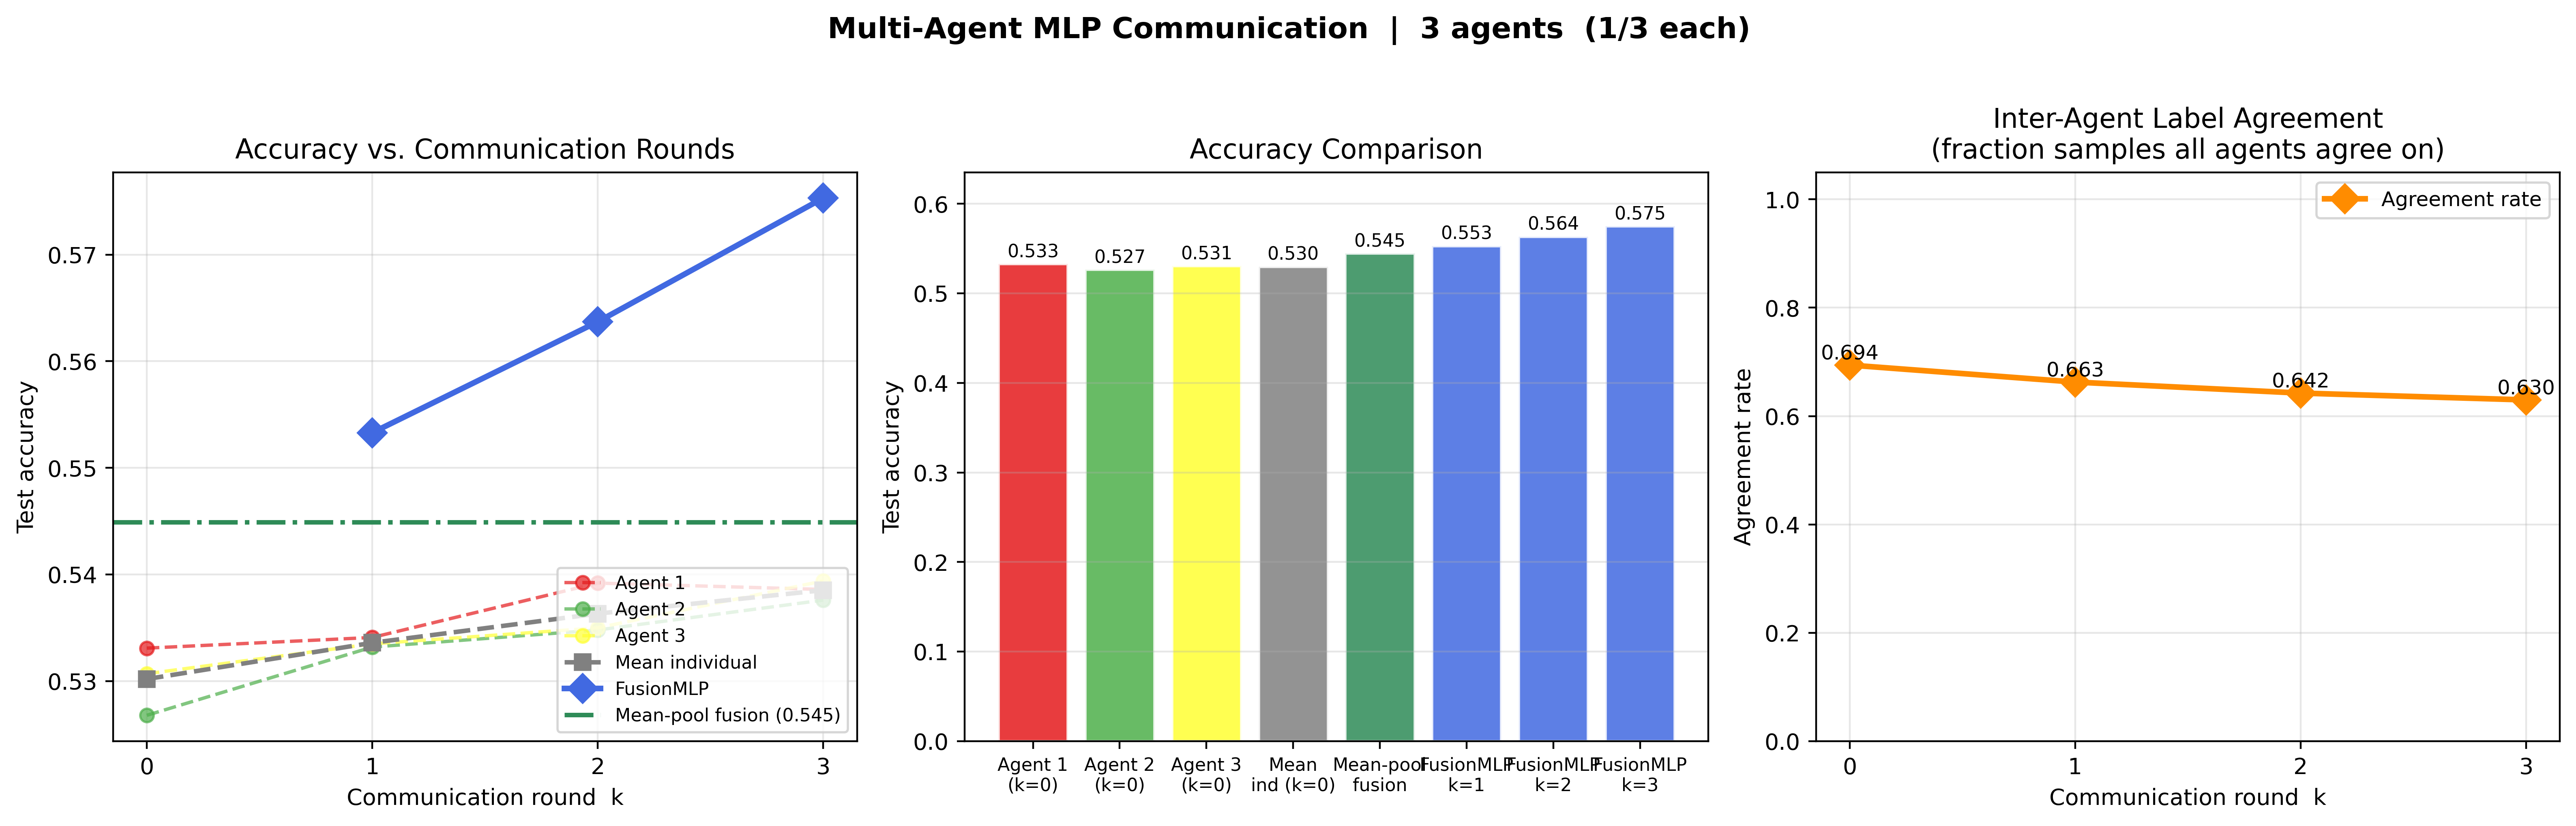

In [1]:
from IPython.display import Image, display
display(Image(filename='./multi_agent_comm.png'))

**通信确实提升了分类性能**

| Method | Acc | delta |
|---|---|---|
| Ind. mean k = 0 | 0.530 | 0.0% |
| Mean-pool fusion | 0.545 | +1.5% |
| FusionMLP k = 1 | 0.553 | +2.3% |
| FusionMLP k = 2 | 0.564 | +3.4% |
| FusionMLP k = 3 | 0.575 | **+4.5%** |

核心结论成立：**用 1/3 的数据训练的 agent，通过 latent 通信后可以逼近甚至超过理论上看到更多数据的效果。**

**FusionMLP 优于 Mean-pool，且随轮数单调递增**

- Mean-pool（无参数融合）仅靠几何平均就带来 +1.5% 提升，说明**三个 agent 的知识本身是互补的**，哪怕简单叠加也有增益；
- FusionMLP 每多通信一轮都有明显提升（0.553 → 0.564 → 0.575），说明**可学习的融合器能持续挖掘跨 agent 的互补信息**，而不是简单平均；
- k = 3 时 FusionMLP（0.575）已超过 Mean-pool（0.545）约 3 个百分点，差距随轮数拉大。

**Agreement rate 下降是一个反直觉但合理的现象**

- agreement 从 k = 0 的 0.694 持续下降到 k = 3 的 0.630，看起来 agent 之间越来越不一致；
- k = 0 时三个 agent 各自在小 shard 上训练，**都倾向于偏向高频类**，预测结果趋同（高 agreement）但整体偏差大（低 acc）；
- 通信微调后，每个 agent 的 backbone 被引导去学不同的互补特征，**分工更细化**，个体预测更分散，agreement 下降；
- 这恰恰说明融合的价值所在**不是让 agent 达成完全一致，而是让它们各自专注于不同的判别维度，再由 FusionMLP 整合**即可。